# Plug and WiFi Busyness Model

This notebook outlines the entire process of the model from fetching data at the start, to training and saving a busyness predictor at the end.

**Target:** A score between 0-100 built for general busyness in the area within which a venue lies. This is achieved by leveraging publicly available data such as MTA subway ridership figures as well as NYC taxi pickups and NYC taxi dropoffs. It is also used as a best-guess live busyness predictor for venues. There are valid alternatives for this (like BestTime API for example), but budget constraints mean that such options were non-runners.

## The Steps

1. Fetch subway ridership and taxi activity.
2. Assign subway stations and venues to TLC taxi zones for training purposes.
3. Aggregate station ridership to zone-hour rows.
4. Merge subway and taxi activity.
5. Transform skewed target and create the 0-100 scoring system.
6. Convert time to trigonometric time.
7. Compare the performance of several models including Extra Trees Regressor, Random Forest, and XGBoost.
8. Save and wrap the best performing model (Random Forest).
9. Load the model through the predictor wrapper and score venues.


## Setup

Run Jupyter from the repository root. The following cell also corrects the working directory if the notebook server starts inside data-ml/notebooks.


In [2]:
import os
os.chdir("../..")

In [ ]:
import math

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Initial subway only prototype and issues.

The first iteration predicted average subway ridership near a venue from station location, weekday/weekend, `subway-line count`, and time features. K-nearest-neighbours, Random Forest, XGBoost, and Extra Trees were explored.

On hearing the demonstrator feedback post-presentation, as well as listening to the presentations of my peers on their models, I soon realised a number of issues with this version that needed to be overhauled for the final application.

- Firstly, KNN won out. I did not realise this as an issue given my limited understanding of ML at that stage, but Mark highlighted that this `should not` be the case. This was the first and largest warning sign to me that something was not right.
- Extremely low R^2 values of ≈ 0.4. Once again, I was not aware that this was a problem until I saw my peers' models scoring in the high 0.9's.
- Attaching the busyness score of a venue to that of the nearest station was just unrealistic on reflection. Often times the nearest geographical station was largely innaccessable due to rivers, pedestrianised areas etc. 
- Simply not enough input data was used. Again, this lends to how little I knew about ML in the early stages of the project where I thought it necessary to prevent the model from growing large and so came up with numerous work arounds such that only 20k rows of mta ridership data was pulled. This is in contrast to the millions of rows pulled in the final model, not to mention the addition of millions of rows of taxi activity data to enhance coverage even more.


## 2. Pulling taxi activity

The TLC files already encode pickup and dropoff taxi-zone IDs. For every month and taxi type, the source script:

- reads pickup time, dropoff time, pickup zone, and dropoff zone.
- rounds the timestamps to the hour.
- counts pickups and dropoffs by zone per hour.
- combines both NYC taxi types: yellow and green.

In [ ]:
%%script true
import pandas as pd

TRIP_URL = (
    "https://d37ci6vzurychx.cloudfront.net/trip-data/"
    "{taxi_type}_tripdata_{month}.parquet"
) #Right cliked the january download to get the address it points to. Can then change taxi type and month to loop through later.

ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv" 


def perhour_perzone_count(trips, time_column, zone_column, count_column, month):
    events = trips[[time_column, zone_column]].copy()
    events[time_column] = pd.to_datetime(events[time_column], errors="coerce")
    events[zone_column] = pd.to_numeric(events[zone_column], errors="coerce")
    events = events.dropna()

    events = events[(events[time_column] >= month.start_time) & (events[time_column] < (month + 1).start_time)]

    events["timestamp"] = events[time_column].dt.floor("h")
    events["zone_id"] = events[zone_column].astype(int)

    return (
        events.groupby(["timestamp", "zone_id"])
        .size()
        .reset_index(name=count_column)
    )


def event_type_count(trips, pickup_time, dropoff_time, month):
    pickups = perhour_perzone_count(
        trips,
        pickup_time,
        "PULocationID",
        "taxi_pickups",
        month
    )
    dropoffs = perhour_perzone_count(
        trips,
        dropoff_time,
        "DOLocationID",
        "taxi_dropoffs",
        month
    )

    return pickups.merge(
        dropoffs,
        on=["timestamp", "zone_id"],
        how="outer"
    ).fillna(0)


def fetch_month(taxi_type, month):
    if taxi_type == "yellow":
        pickup_time = "tpep_pickup_datetime"
        dropoff_time = "tpep_dropoff_datetime"
    else:
        pickup_time = "lpep_pickup_datetime"
        dropoff_time = "lpep_dropoff_datetime"

    url = TRIP_URL.format(taxi_type=taxi_type, month=month)

    trips = pd.read_parquet(
        url,
        columns=[
            pickup_time,
            dropoff_time,
            "PULocationID",
            "DOLocationID"
        ]
    )

    return event_type_count(
        trips,
        pickup_time,
        dropoff_time,
        month
    )


def fetch_taxi_data():
    monthly_activity = []

    for month in pd.period_range("2023-01", "2023-12", freq="M"):
        for taxi_type in ["yellow", "green"]:
            print(f"Loading {taxi_type} taxi data for {month}")
            monthly_activity.append(fetch_month(taxi_type, month))

    activity = pd.concat(monthly_activity)
    activity = activity.groupby(["timestamp", "zone_id"], as_index=False)[["taxi_pickups", "taxi_dropoffs"]].sum()

    zones = pd.read_csv(ZONE_URL)
    zones = zones.rename(
        columns={
            "LocationID": "zone_id",
            "Borough": "borough",
            "Zone": "taxi_zone"
        }
    )

    nyc_boroughs = [
        "Bronx",
        "Brooklyn",
        "Manhattan",
        "Queens",
        "Staten Island"
    ]
    zones = zones[zones["borough"].isin(nyc_boroughs)]

    activity = activity.merge(zones[["zone_id", "borough", "taxi_zone"]], on="zone_id")
    activity["taxi_activity"] = (activity["taxi_pickups"] + activity["taxi_dropoffs"])

    activity["date"] = activity["timestamp"].dt.date
    activity["hour"] = activity["timestamp"].dt.hour
    activity["day_of_week"] = activity["timestamp"].dt.dayofweek
    activity["day_type"] = activity["day_of_week"].apply(
        lambda day: "weekend" if day >= 5 else "weekday"
    )

    activity = activity.sort_values(["timestamp", "zone_id"])
    activity.to_csv("data/processed/taxi_activity_hourly.csv", mode="a", header=False, index=False)

    return activity


if __name__ == "__main__":
    fetch_taxi_data()


## 3. Pulling hourly MTA ridership

The 2023–2024 archive uses dataset wujg-7c2s and 2025 onward uses 5wq4-mkjj.

In [ ]:
%%script true
import pandas as pd
from sodapy import Socrata


client = Socrata("data.ny.gov", None, timeout=300)

output = "data/processed/mta_ridership_2023_hourly.csv"
first_month = True

for month in pd.period_range("2023-01", "2023-12", freq="M"):
    start = month.start_time.strftime("%Y-%m-%dT%H:%M:%S")
    end = (month + 1).start_time.strftime("%Y-%m-%dT%H:%M:%S")
    dataset_id = "wujg-7c2s" if month.year <= 2024 else "5wq4-mkjj"

    print(f"Downloading MTA ridership for {month}")

    results = client.get_all(
        dataset_id,
        select=(
            "station_complex_id, station_complex, borough, latitude, "
            "longitude, date_trunc_ymd(transit_timestamp) AS date, "
            "date_extract_hh(transit_timestamp) AS hour, "
            "sum(ridership) AS total_ridership, "
            "case(date_extract_dow(transit_timestamp) IN (0,6), "
            "'weekend', true, 'weekday') AS day_type"
        ),
        where=(
            f"transit_timestamp >= '{start}' "
            f"AND transit_timestamp < '{end}'"
        ),
        group=(
            "station_complex_id, station_complex, borough, latitude, "
            "longitude, date_trunc_ymd(transit_timestamp), "
            "date_extract_hh(transit_timestamp), "
            "case(date_extract_dow(transit_timestamp) IN (0,6), "
            "'weekend', true, 'weekday')"
        ),
        order=(
            "date_trunc_ymd(transit_timestamp), "
            "date_extract_hh(transit_timestamp), station_complex_id"
        ),
        limit=50000
    )

    results_df = pd.DataFrame.from_records(results)

    if results_df.empty:
        raise RuntimeError(f"No MTA ridership data returned for {month}")

    for col in ["total_ridership", "latitude", "longitude", "hour"]:
        results_df[col] = pd.to_numeric(results_df[col])

    results_df["date"] = pd.to_datetime(results_df["date"]).dt.date

    results_df.to_csv(
        output,
        mode="w" if first_month else "a",
        header=first_month,
        index=False
    )

    first_month = False
    print(f"Saved {len(results_df):,} rows for {month}")


## 4. Assigning MTA rows to taxi zones

A taxi-zone shapefile contains the polygon geometry needed for to ascertain the bounds of a zone.

MTA latitude/longitude is in EPSG:4326, the standard degree cooridnate system. However, the taxi zone shapefile is in EPSG:2263 which is a New York / Long Island corrdinate system measured in feet. Thus a projection is required on the station coordinates before joining with the zone they lie within.

In [ ]:
%%script true
from pathlib import Path

import geopandas as gpd
import pandas as pd


mta_file = Path("data/processed/mta_ridership_2023_hourly.csv")
mta = pd.read_csv(mta_file)
mta = mta.drop(columns=["zone_id"], errors="ignore")

zone_file = Path("data/raw/tlc/taxi_zones.zip")

zones = gpd.read_file(f"zip://{zone_file}!taxi_zones/taxi_zones.shp")
zones = zones.rename(columns={"LocationID": "zone_id"})

station_locations = mta[["station_complex_id", "latitude", "longitude"]].drop_duplicates()

station_locations = gpd.GeoDataFrame(
    station_locations,
    geometry=gpd.points_from_xy(
        station_locations["longitude"],
        station_locations["latitude"]
    ),
    crs="EPSG:4326"
).to_crs(zones.crs)

station_zones = gpd.sjoin(
    station_locations,
    zones[["zone_id", "geometry"]],
    how="left",
    predicate="within",
)[["station_complex_id", "latitude", "longitude", "zone_id"]]

mta = mta.merge(station_zones, on=["station_complex_id", "latitude", "longitude"])

mta["zone_id"] = mta["zone_id"].astype(int)

mta_by_zone = (
    mta.groupby(
        ["zone_id", "date", "hour", "day_type"],
        as_index=False,
    )["total_ridership"]
    .sum()
    .rename(columns={"total_ridership": "mta_ridership"})
)
mta_by_zone.to_csv(
    "data/processed/mta_zone_hourly.csv",
    mode="a",
    header=False,
    index=False
)

mta.to_csv(
    "data/processed/mta_ridership_hourly.csv",
    mode="a",
    header=False,
    index=False
)


In [ ]:
mta_zone_sample = pd.read_csv(
    "data/processed/mta_zone_hourly.csv",
    nrows=10
)

mta_zone_sample


,zone_id,date,hour,day_type,mta_ridership
0,3,2024-01-01,0,weekday,6.0
1,3,2024-01-01,1,weekday,15.0
2,3,2024-01-01,2,weekday,11.0
3,3,2024-01-01,3,weekday,5.0
4,3,2024-01-01,4,weekday,12.0
5,3,2024-01-01,5,weekday,51.0
6,3,2024-01-01,6,weekday,67.0
7,3,2024-01-01,7,weekday,65.0
8,3,2024-01-01,8,weekday,75.0
9,3,2024-01-01,9,weekday,61.0


## 5. Assigning venues to the same zones

The same operation as above assigns a zone_id to each venue.

In [ ]:
%%script true
from pathlib import Path

import geopandas as gpd
import pandas as pd
import requests


venue_file = Path("data/processed/nyc_venues.csv")
venues = pd.read_csv(venue_file)
venues = venues.drop(columns=["zone_id"], errors="ignore")

zone_file = Path("data/raw/tlc/taxi_zones.zip")
if not zone_file.exists():
    zone_file.parent.mkdir(parents=True, exist_ok=True)
    response = requests.get("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip")
    response.raise_for_status()
    zone_file.write_bytes(response.content)

zones = gpd.read_file(f"zip://{zone_file}!taxi_zones/taxi_zones.shp")
zones = zones.rename(columns={"LocationID": "zone_id"})

venue_points = gpd.GeoDataFrame(venues, geometry=gpd.points_from_xy(venues["lon"], venues["lat"]), crs="EPSG:4326").to_crs(zones.crs)

venues = gpd.sjoin(venue_points, zones[["zone_id", "geometry"]], how="left", predicate="within").drop(columns=["geometry", "index_right"])

venues["zone_id"] = venues["zone_id"].astype("Int64")

temporary_file = venue_file.with_suffix(".temporary.csv")
venues.to_csv(temporary_file, index=False)
temporary_file.replace(venue_file)



In [ ]:
venue_zone_check = pd.read_csv(
    "data/processed/nyc_venues.csv",
    usecols=["venue_id", "name", "lat", "lon", "zone_id"]
)

pd.Series(
    {
        "venues": len(venue_zone_check),
        "venues_with_zone": venue_zone_check["zone_id"].notna().sum(),
        "venues_without_zone": venue_zone_check["zone_id"].isna().sum(),
        "unique_assigned_zones": venue_zone_check["zone_id"].nunique()
    }
)


venues                   13882
venues_with_zone         11753
venues_without_zone       2129
unique_assigned_zones      244
dtype: int64

## 6. Merging subway ridership with taxi activity and defining the target

Missing values are set equal to zero.

Two taxi values are retained:
- taxi_activity = taxi_pickups + taxi_dropoffs
- taxi_net_arrivals = taxi_dropoffs - taxi_pickups

In [ ]:
%%script true
import pandas as pd
import numpy as np


mta = pd.read_csv("data/processed/mta_zone_hourly.csv")

taxi = pd.read_csv(
    "data/processed/taxi_activity_hourly.csv",
    usecols=[
        "zone_id",
        "date",
        "hour",
        "day_of_week",
        "day_type",
        "taxi_pickups",
        "taxi_dropoffs",
        "taxi_activity"
    ]
)

zone_activity = taxi.merge(
    mta,
    on=["zone_id", "date", "hour", "day_type"],
    how="outer"
)

zone_activity[
    [
        "mta_ridership",
        "taxi_pickups",
        "taxi_dropoffs",
        "taxi_activity"
    ]
] = zone_activity[
    [
        "mta_ridership",
        "taxi_pickups",
        "taxi_dropoffs",
        "taxi_activity"
    ]
].fillna(0)

zone_activity["taxi_net_arrivals"] = (
    zone_activity["taxi_dropoffs"]
    - zone_activity["taxi_pickups"]
)

zone_activity["log_mta_ridership"] = np.log1p(zone_activity["mta_ridership"])
zone_activity["log_taxi_activity"] = np.log1p(zone_activity["taxi_activity"])
zone_activity["log_taxi_net_arrivals"] = (
    np.sign(zone_activity["taxi_net_arrivals"])
    * np.log1p(np.abs(zone_activity["taxi_net_arrivals"]))
)

zone_activity["date"] = pd.to_datetime(zone_activity["date"])
training_rows = zone_activity["date"] < "2025-01-01"

mta_high = zone_activity.loc[
    training_rows, "log_mta_ridership"
].quantile(0.99)
taxi_high = zone_activity.loc[
    training_rows, "log_taxi_activity"
].quantile(0.99)
net_high = zone_activity.loc[
    training_rows, "log_taxi_net_arrivals"
].abs().quantile(0.99)

zone_activity["mta_score"] = (
    zone_activity["log_mta_ridership"] / mta_high
).clip(0, 1)
zone_activity["taxi_activity_score"] = (
    zone_activity["log_taxi_activity"] / taxi_high
).clip(0, 1)
zone_activity["taxi_net_arrivals_score"] = (
    zone_activity["log_taxi_net_arrivals"] / net_high
).clip(-1, 1)

zone_activity["busyness_score"] = (
    (
        0.75 * zone_activity["mta_score"]
        + 0.2 * zone_activity["taxi_activity_score"]
        + 0.05 * zone_activity["taxi_net_arrivals_score"]
    ).clip(0, 1)
    * 100
)

zone_activity.to_csv(
    "data/processed/zone_activity_hourly.csv",
    index=False
)


In [6]:
import numpy as np

activity_columns = [
    "zone_id",
    "date",
    "hour",
    "mta_ridership",
    "taxi_pickups",
    "taxi_dropoffs",
    "taxi_activity",
    "taxi_net_arrivals",
    "log_mta_ridership",
    "log_taxi_activity",
    "log_taxi_net_arrivals",
    "busyness_score"
]

zone_activity = pd.read_csv(
    "data/processed/zone_activity_hourly.csv",
    usecols=activity_columns
)

zone_activity["date"] = pd.to_datetime(zone_activity["date"])

mta_observations = pd.read_csv(
    "data/processed/mta_zone_hourly.csv",
    usecols=["mta_ridership"]
)
mta_observations["log_mta_ridership"] = np.log1p(
    mta_observations["mta_ridership"]
)

pd.Series(
    {
        "rows": len(zone_activity),
        "first_date": zone_activity["date"].min(),
        "last_date": zone_activity["date"].max(),
        "zones": zone_activity["zone_id"].nunique()
    }
)


rows                      6114341
first_date    2023-01-01 00:00:00
last_date     2026-04-30 00:00:00
zones                         260
dtype: object

### Why log transform the target?

Hourly counts are strongly right-skewed

log1p(x) means log(1 + x), so zero remains valid.
MTA ridership and total taxi activity are non-negative.
Taxi net arrivals can be negative, so its sign is saved while log1p is applied to its absolute magnitude.

The scores are then normalised between 0 and 1 so that they can be combined cleanly. This is done by dividing each ridership value by the 99th percentile value and clipping between 0 and 1.

These normalised scores are then combined



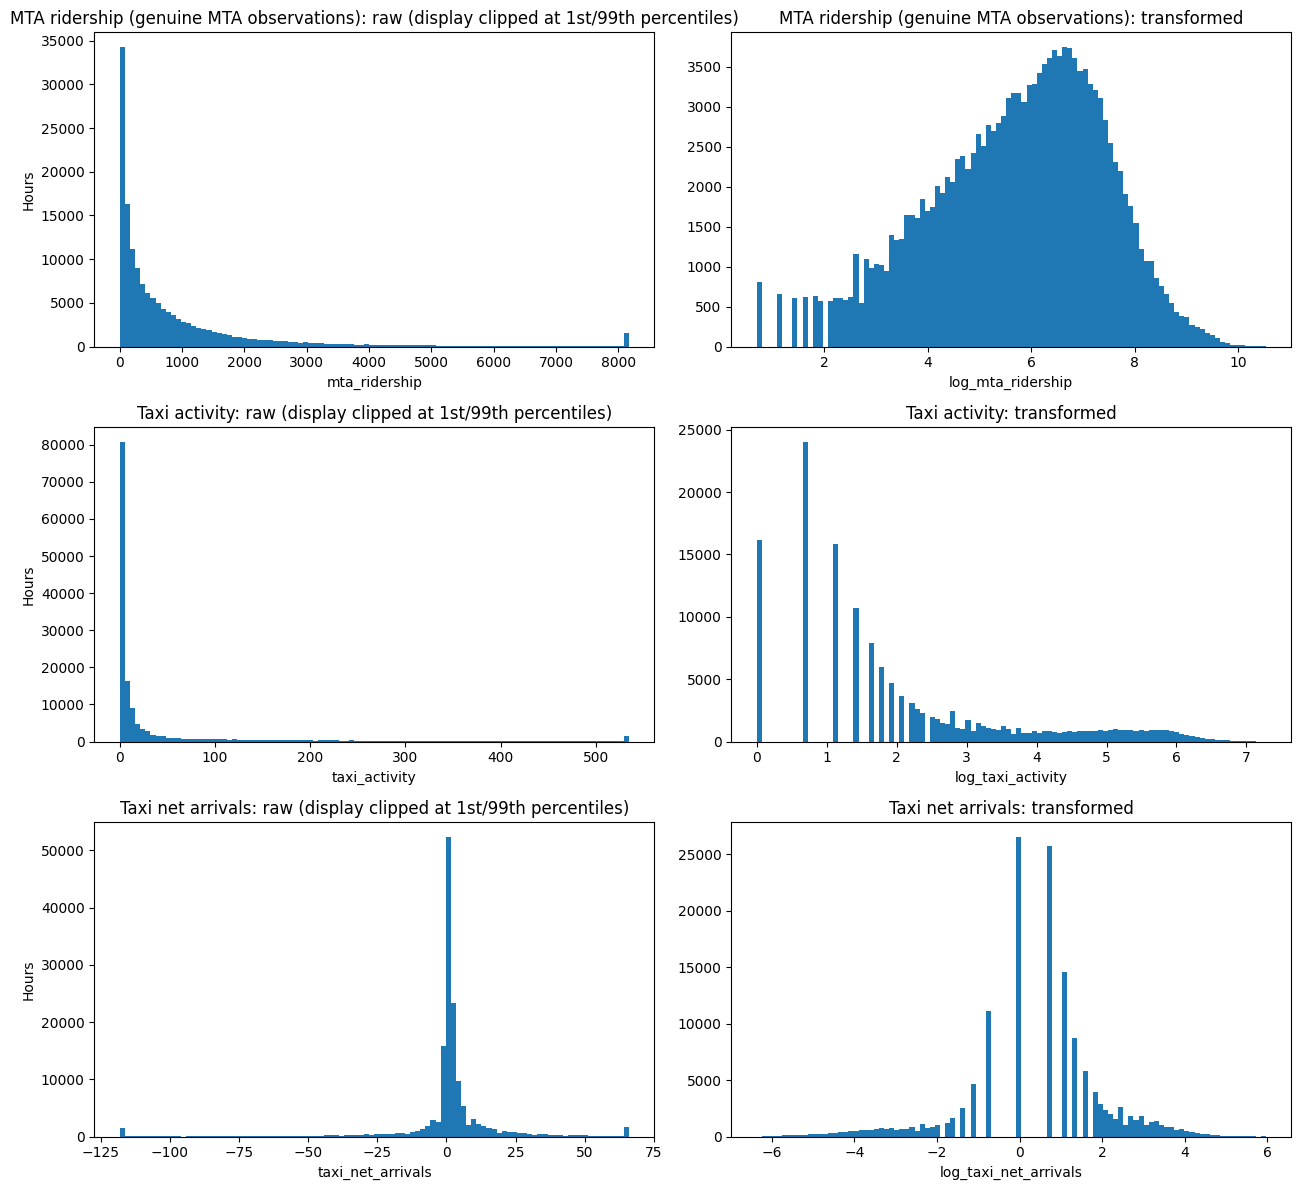

In [7]:
mta_plot_sample = mta_observations.sample(
    n=min(150000, len(mta_observations)),
    random_state=1
)
zone_plot_sample = zone_activity.sample(
    n=min(150000, len(zone_activity)),
    random_state=1
)

pairs = [
    (
        mta_plot_sample,
        "mta_ridership",
        "log_mta_ridership",
        "MTA ridership (genuine MTA observations)"
    ),
    (
        zone_plot_sample,
        "taxi_activity",
        "log_taxi_activity",
        "Taxi activity"
    ),
    (
        zone_plot_sample,
        "taxi_net_arrivals",
        "log_taxi_net_arrivals",
        "Taxi net arrivals"
    )
]

fig, axes = plt.subplots(3, 2, figsize=(13, 12))

for row, (sample, raw_column, log_column, title) in enumerate(pairs):
    raw = sample[raw_column]
    lower = raw.quantile(0.01)
    upper = raw.quantile(0.99)

    axes[row, 0].hist(raw.clip(lower, upper), bins=100)
    axes[row, 0].set_title(f"{title}: raw (display clipped at 1st/99th percentiles)")
    axes[row, 0].set_xlabel(raw_column)
    axes[row, 0].set_ylabel("Hours")

    axes[row, 1].hist(sample[log_column], bins=100)
    axes[row, 1].set_title(f"{title}: transformed")
    axes[row, 1].set_xlabel(log_column)
    axes[row, 0].set_ylabel("Hours")

plt.tight_layout()
plt.show()


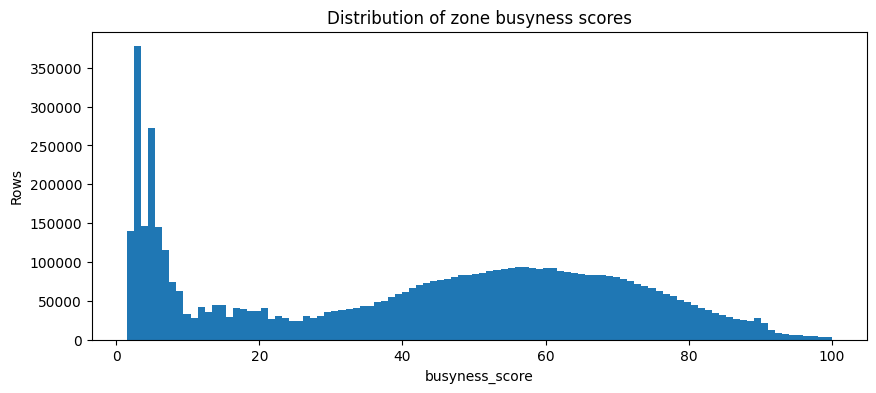

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(zone_activity["busyness_score"], bins=100)
ax.set_title("Distribution of zone busyness scores")
ax.set_xlabel("busyness_score")
ax.set_ylabel("Rows")
plt.show()


On the current processed dataset there are 4,335,287 rows, one for each zone at each hour. The median score is about 41.2, the 25th percentile about 19.8, and the 75th percentile about 58.9 giving the score has a realistic spread and making it a meaningful quantity.


## 7. Trigonometric Time

Initially, hours are stored as integers 0-23. However, for training purposes, the model must be made aware that the hours of 23:00 and 00:00 are actually very closely related. Using raw integers to describe these times fails in this task. Therefore we must use a cyclical representation of time which is done by applying a simple trigonometric transformation using sine and cosine.

We extend this idea to the representation of specific dates also. The model must be made to know that the 31st of December is very close in proximity to the 1st of January despite the fact that when integer encoded (12 and 0 respectively) they seem very far away.




The model files use the following exact feature transformation:


In [ ]:
demo_df = pd.read_csv(
    "data/processed/zone_activity_hourly.csv",
    usecols=["zone_id", "date", "hour", "busyness_score"]
)

demo_df["date"] = pd.to_datetime(demo_df["date"])
demo_df["day_of_week"] = demo_df["date"].dt.dayofweek
demo_df["month"] = demo_df["date"].dt.month
demo_df["is_weekend"] = (demo_df["day_of_week"] >= 5).astype(int)

demo_df["hour_sin"] = np.sin(2 * np.pi * demo_df["hour"] / 24)
demo_df["hour_cos"] = np.cos(2 * np.pi * demo_df["hour"] / 24)
demo_df["day_sin"] = np.sin(2 * np.pi * demo_df["day_of_week"] / 7)
demo_df["day_cos"] = np.cos(2 * np.pi * demo_df["day_of_week"] / 7)
demo_df["month_sin"] = np.sin(2 * np.pi * demo_df["month"] / 12)
demo_df["month_cos"] = np.cos(2 * np.pi * demo_df["month"] / 12)

demo_df_train = demo_df[demo_df["date"] < "2025-01-01"]
demo_df_zone_baselines = demo_df_train.groupby("zone_id")["busyness_score"].mean()
demo_df["zone_baseline"] = demo_df["zone_id"].map(demo_df_zone_baselines)

demo_df.head()


,zone_id,date,hour,busyness_score,day_of_week,month,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2,2024-01-04,5,4.81569,3,1,0,0.965926,0.258819,0.433884,-0.900969,0.5,0.866025
1,2,2024-01-06,23,4.81569,5,1,1,-0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025
2,2,2024-01-08,22,4.81569,0,1,0,-0.500000,0.866025,0.000000,1.000000,0.5,0.866025
3,2,2024-01-11,19,6.23090,3,1,0,-0.965926,0.258819,0.433884,-0.900969,0.5,0.866025
4,2,2024-01-27,2,6.23090,5,1,1,0.500000,0.866025,-0.974928,-0.222521,0.5,0.866025


The models are trained on 2023-2024 data and tests on 2025 data, giving an approximately 2:1 train test split.

In [ ]:
train_df = demo_df[demo_df["date"] < "2025-01-01"].copy()
test_df = demo_df[
    (demo_df["date"] >= "2025-01-01")
    & (demo_df["date"] < "2026-01-01")
].copy()

pd.Series(
    {
        "training_rows": len(train_df),
        "training_start": train_df["date"].min(),
        "training_end": train_df["date"].max(),
        "testing_rows": len(test_df),
        "testing_start": test_df["date"].min(),
        "testing_end": test_df["date"].max()
    }
)


training_rows                 1810407
training_start    2024-01-01 00:00:00
training_end      2024-12-31 00:00:00
testing_rows                  1899950
testing_start     2025-01-01 00:00:00
testing_end       2025-12-31 00:00:00
dtype: object

## 9. Model 1 — Extra Trees

In [ ]:
import math

import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



df = pd.read_csv("data/processed/zone_activity_hourly.csv", usecols=["zone_id", "date", "hour", "busyness_score"])

df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

train_df = df[df["date"] < "2025-01-01"].copy()
test_df = df[(df["date"] >= "2025-01-01") & (df["date"] < "2026-01-01")].copy()

train_zone_baselines = train_df.groupby("zone_id")["busyness_score"].mean()

train_df["zone_baseline"] = train_df["zone_id"].map(train_zone_baselines)
test_df["zone_baseline"] = test_df["zone_id"].map(train_zone_baselines)

feat = [
    "zone_baseline",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos"
]

x_train = train_df[feat]
y_train = train_df["busyness_score"]

x_test = test_df[feat]
y_test = test_df["busyness_score"]

xt_model = ExtraTreesRegressor(
    n_estimators= 25,
    max_features = 6,
    min_samples_leaf = 50,
    random_state = 1,
    n_jobs = -1
)
xt_model.fit(x_train, y_train)
xt_pred = xt_model.predict(x_test)

print("Extra Trees Regressor")
print(f"MAE: {mean_absolute_error(y_test, xt_pred)}")
print(f"RMSE: {math.sqrt(mean_squared_error(y_test, xt_pred))}")
print(f"r2: {r2_score(y_test, xt_pred)}")


Extra Trees Regressor
MAE: 5.619090879570819
RMSE: 7.958552916489185
r2: 0.8984644142357542


## 10. Model 2 — Random Forest


In [12]:
import math

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("data/processed/zone_activity_hourly.csv",usecols=["zone_id", "date", "hour", "busyness_score"])

df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

train_df = df[df["date"] < "2025-01-01"].copy()
test_df = df[(df["date"] >= "2025-01-01") & (df["date"] < "2026-01-01")].copy()

train_zone_baselines = train_df.groupby("zone_id")["busyness_score"].mean()

train_df["zone_baseline"] = train_df["zone_id"].map(train_zone_baselines)
test_df["zone_baseline"] = test_df["zone_id"].map(train_zone_baselines)

feat = [
    "zone_baseline",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
]

x_train = train_df[feat]
y_train = train_df["busyness_score"]

x_test = test_df[feat]
y_test = test_df["busyness_score"]

rf_model = RandomForestRegressor(
    n_estimators= 25,
    max_features = 6,
    min_samples_leaf = 50,
    random_state = 1,
    n_jobs = -1
)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

print("Random Forest Regressor")
print(f"MAE: {mean_absolute_error(y_test, rf_pred)}")
print(f"RMSE: {math.sqrt(mean_squared_error(y_test, rf_pred))}")
print(f"r2: {r2_score(y_test, rf_pred)}")

final_zone_baselines = df.groupby("zone_id")["busyness_score"].mean()
df["zone_baseline"] = df["zone_id"].map(final_zone_baselines)

final_model = RandomForestRegressor(
    n_estimators= 25,
    max_features = 6,
    min_samples_leaf = 50,
    random_state = 1,
    n_jobs = -1
)
final_model.fit(df[feat], df["busyness_score"])

joblib.dump(
    {
        "model": final_model,
        "feature_names": feat,
        "target": "busyness_score",
        "zone_baselines": final_zone_baselines.to_dict()
    },
    "data-ml/models/zone_busyness_model.joblib"
)


Random Forest Regressor
MAE: 4.136571250262729
RMSE: 8.526707564619281
r2: 0.9063541567501533


['data-ml/models/zone_busyness_model.joblib']

## 11. Model 3 — XGBoost

This is the exact current data-ml/models/xg_zone_busyness_model.py code.


In [57]:
import math

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor


df = pd.read_csv( "data/processed/zone_activity_hourly.csv", usecols=["zone_id", "date", "hour", "busyness_score"])

df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

train_df = df[df["date"] < "2025-01-01"].copy()
test_df = df[(df["date"] >= "2025-01-01") & (df["date"] < "2026-01-01")].copy()

train_zone_baselines = train_df.groupby("zone_id")["busyness_score"].mean()

train_df["zone_baseline"] = train_df["zone_id"].map(train_zone_baselines)
test_df["zone_baseline"] = test_df["zone_id"].map(train_zone_baselines)

feat = [
    "zone_baseline",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos"
]

x_train = train_df[feat]
y_train = train_df["busyness_score"]

x_test = test_df[feat]
y_test = test_df["busyness_score"]

xg_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=1,
    n_jobs=-1
)
xg_model.fit(x_train, y_train)
xg_pred = xg_model.predict(x_test)

print("XGBoost Regressor")
print(f"MAE: {mean_absolute_error(y_test, xg_pred)}")
print(f"RMSE: {math.sqrt(mean_squared_error(y_test, xg_pred))}")
print(f"r2: {r2_score(y_test, xg_pred)}")


XGBoost Regressor
MAE: 5.726810205559682
RMSE: 8.05514174005403
r2: 0.8959848892904771


## 12. Model results

The **Random Forest is the best of the three trained regressors**


In [ ]:
recorded_results = pd.DataFrame(
    {
        "method": [
            "Random Forest",
            "Extra Trees",
            "XGBoost"
        ],
        "MAE": [5.329150, 5.433156, 5.464781],
        "RMSE": [7.703602, 7.800621, 7.818698],
        "R2": [0.904192, 0.901764, 0.901308]
    }
).sort_values("RMSE")

recorded_results


,method,MAE,RMSE,R2
0,Random Forest,5.329150,7.703602,0.904192
1,Extra Trees,5.433156,7.800621,0.901764
2,XGBoost,5.464781,7.818698,0.901308


## 13. RF Feature Importance


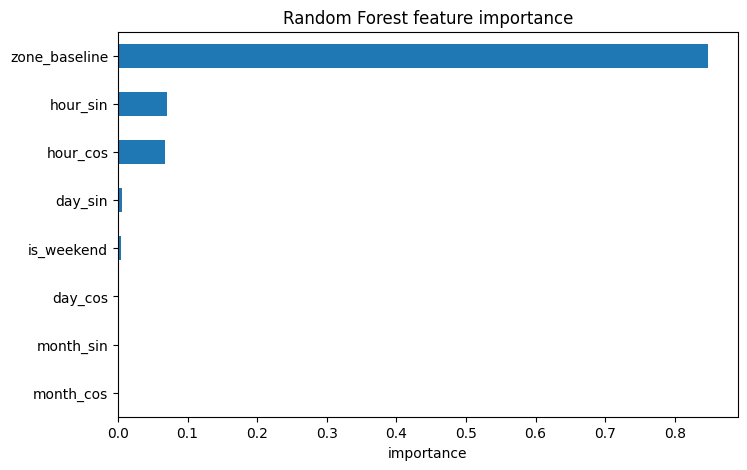

In [61]:
feature_importance = (
    pd.Series(rf_model.feature_importances_, index=feat)
    .sort_values()
)

feature_importance.plot.barh(figsize=(8, 5), title="Random Forest feature importance")
plt.xlabel("importance")
plt.show()



## 14. Saved model artifact and predictor wrapper

The Random Forest file stores:

- the fitted model
- the exact ordered feature names
- the target name
- the historical mean busyness stored for each zone.

ZoneBusynessPredictor is wrapper class for the model and provides a means through which to ensure that the model receives the features converted in the appropriate way (e.g. Trig Time).

In [62]:
import joblib
import numpy as np
import pandas as pd


class ZoneBusynessPredictor:
    def __init__(self,  model_path="data-ml/models/zone_busyness_model.joblib"):
        saved = joblib.load(model_path)
        if "zone_baselines" not in saved:
            raise RuntimeError(
                "This model artifact predates zone-mean encoding. "
                "Run data-ml/models/rf_zone_busyness_model.py to retrain it."
            )

        self.model = saved["model"]
        self.feature_names = saved["feature_names"]
        self.zone_baselines = saved["zone_baselines"]

    def predict_many(self, venues, date, hour):
        if isinstance(venues, dict):
            venues = pd.DataFrame([venues])
        elif isinstance(venues, pd.Series):
            venues = pd.DataFrame([venues])
        else:
            venues = venues.copy()

        date = pd.Timestamp(date)
        venues["is_weekend"] = int(date.dayofweek >= 5)
        venues["hour_sin"] = np.sin(2 * np.pi * hour / 24)
        venues["hour_cos"] = np.cos(2 * np.pi * hour / 24)
        venues["day_sin"] = np.sin(2 * np.pi * date.dayofweek / 7)
        venues["day_cos"] = np.cos(2 * np.pi * date.dayofweek / 7)
        venues["month_sin"] = np.sin(2 * np.pi * date.month / 12)
        venues["month_cos"] = np.cos(2 * np.pi * date.month / 12)
        venues["zone_baseline"] = venues["zone_id"].map(self.zone_baselines)

        valid = venues["zone_id"].notna() & venues["zone_baseline"].notna()
        venues["busyness_score"] = pd.NA

        if valid.any():
            scores = self.model.predict(venues.loc[valid, self.feature_names])
            venues.loc[valid, "busyness_score"] = (np.clip(scores, 0, 100).round().astype(int))

        results = []
        for _ , venue in venues.iterrows():
            score = venue["busyness_score"]
            if pd.isna(score):
                label = "Unavailable"
                score = None
            else:
                score = int(score)
                if score <= 33:
                    label = "Low"
                elif score <= 66:
                    label = "Medium"
                else:
                    label = "High"

            results.append(
                {
                    "venue_id": venue["venue_id"],
                    "busyness_score": score,
                    "busyness_label": label
                }
            )

        return results

    def predict_one(self, venue, date, hour):
        return self.predict_many(venue, date, hour)[0]


def load_zone_busyness_predictor():
    return ZoneBusynessPredictor()


### Testing a batch of venues

Because each venue already has zone_id, the predictor only needs a date and hour. All venues in one zone receive the same zone-level estimate for the same time.


In [ ]:
venues = pd.read_csv("data/processed/nyc_venues.csv")
predictor = load_zone_busyness_predictor()

result = predictor.predict_many(
    venues.iloc[2:20],
    date="2026-07-17",
    hour=14
)

pd.DataFrame(result)


,venue_id,busyness_score,busyness_label
0,osm_357618253,11,Low
1,osm_357620442,38,Medium
2,osm_368043718,89,High
3,osm_368061418,82,High
4,osm_368061423,82,High
5,osm_380044344,59,Medium
6,osm_410235438,65,Medium
7,osm_411504676,6,Low
8,osm_418520887,19,Low
9,osm_418524116,32,Low


## 15. What the model allows

The model does not require future taxi pickups, taxi dropoffs, or MTA subway ridership. Those values were only used to build the target.

At calculation time, the model needs to be provided with a zone_id, a day-type, trigonometric time, trigonometric week and, trigonometric month.

This is why it can score a future date such as 17 July 2027. It learns the recurring calendar pattern of the historical busyness target for each zone.

**Important limitations:**

1. The 0.75 MTA, 0.20 taxi-activity, and 0.05 net-arrival weights are modelling choices based off the reported usage of subways in comparison to taxis in NYC. Their selection is not an exact science.

2. MTA data represents entries, not hourly exits.

3. A venue shares its prediction with every other venue in its taxi zone (260 zones).

4. Venue specific capacity, opening hours, holidays, and special events are absent.

5. Scores beyond the training period assumes that the seasonality present in the data continues.

6. Venues without a valid zone return unavailable. These are mostly in areas well outside the city limits and where the busyness level can be assumed to be extremely low.


## 16. Reproducibility 
What order to run files in:

1. data-ml/src/fetch_taxi.py data-ml/src/fetch_turnstiles.py
2. data-ml/src/turnstile_zone_assignment.py
3. data-ml/src/merge_zones.py
4. data-ml/models/rf_zone_busyness_model.py

# Appendix: 
## Earlier MTA-only KNN and Random Forest models

The previously referenced models used at the individual presentation stage are shown below. These are the KNN and RF models that were heavily critiqued and later overhauled completely.

Note that these use only hourly mta subway ridership data. 20% of stations are held out for the test split.

Initially it seemed KNN was a good fit for a spacial interpolation problem such as this one. However, the results would prove to be mediocre at best.


## K Nearest Neighbours

MAE (K=1): 220.1
MAE (K=10): 206.2
RMSE (k=10): 645.0
R2: 0.416


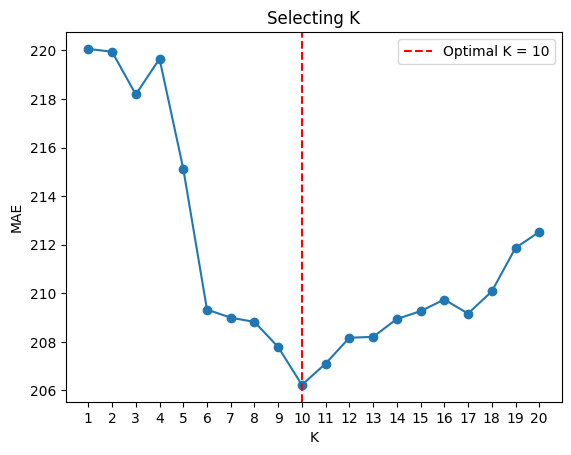

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import re

df = pd.read_csv("data/processed/mta_ridership.csv")

df["log_avg_ridership"] = np.log(df["avg_ridership"])



rng = np.random.default_rng(50)

station_ids = df["station_complex_id"].unique()
n_test = int(0.2 * len(station_ids))
test_ids = rng.choice(station_ids, size=n_test, replace=False)

test_df  = df[df["station_complex_id"].isin(test_ids)].copy()
train_df = df.drop(test_df.index).copy()

train_stations = train_df[["station_complex_id", "latitude", "longitude"]].drop_duplicates().reset_index(drop=True)

K=1

knn = NearestNeighbors(n_neighbors=K).fit(train_stations[["latitude", "longitude"]].to_numpy())

lookup = train_df.set_index(["station_complex_id", "hour", "day_type"])["log_avg_ridership"]

def predict(lat, lon, hour, day_type, k=K):
    dists, idxs = knn.kneighbors([[lat, lon]], n_neighbors = k)
    dists, idxs = dists[0], idxs[0]

    vals, weights = [], []
    for d, i in zip(dists, idxs):
        sid = train_stations.loc[i, "station_complex_id"]
        key = (sid, hour, day_type)
        if key in lookup.index:
            vals.append(lookup.loc[key])
            weights.append(1.0/(d + 1e-12))
    
    if not vals:
        return np.nan
    return np.exp(np.average(vals, weights=weights))




test_df["pred_knn"] = test_df.apply(
    lambda r: predict(r["latitude"], r["longitude"], r["hour"], r["day_type"], k=10), axis=1)

test_df["pred_baseline"] = test_df.apply(
    lambda r: predict(r["latitude"], r["longitude"], r["hour"], r["day_type"], k=1), axis=1)

def mae(pred, actual):
    m = pred.notna() & actual.notna()
    return mean_absolute_error(actual[m], pred[m])


print(f"MAE (K=1): {round(mae(test_df["pred_baseline"], test_df["avg_ridership"]), 1)}")
print(f"MAE (K=10): {round(mae(test_df["pred_knn"], test_df["avg_ridership"]), 1)}")

valid = test_df["pred_knn"].notna() & test_df["avg_ridership"].notna()
y_true = test_df.loc[valid, "avg_ridership"]
y_pred = test_df.loc[valid, "pred_knn"]

print(f"RMSE (k=10): {round(math.sqrt(mean_squared_error(y_true, y_pred)), 1)}")
print(f"R2: {round(r2_score(y_true, y_pred), 3)}")

# Compare the MAE produced by different values of K.
k_values = range(1, 21)
k_mae = []

for k in k_values:
    predictions = test_df.apply(
        lambda r: predict(
            r["latitude"], r["longitude"], r["hour"], r["day_type"], k=k
        ),
        axis=1
    )
    k_mae.append(mae(predictions, test_df["avg_ridership"]))

best_k = list(k_values)[int(np.argmin(k_mae))]

plt.plot(k_values, k_mae, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Optimal K = {best_k}")
plt.xlabel("K")
plt.ylabel("MAE")
plt.title("Selecting K")
plt.xticks(list(k_values))
plt.legend()
plt.show()


## Random Forest

In [79]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re

df = pd.read_csv("data/processed/mta_ridership.csv")

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["is_morning_peak"] = df["hour"].between(7, 10).astype(int)
df["is_evening_peak"] = df["hour"].between(16, 19).astype(int)
df["is_late_night"] = df["hour"].between(0, 5).astype(int)

def extract_subway_lines(station_complex):
    groups = re.findall(r"\(([^()]*)\)", str(station_complex))

    route_group = groups[-1]
    return [line.strip() for line in route_group.split(",")]

df["subway_lines"] = df["station_complex"].apply(extract_subway_lines)
df["line_count"] = df["subway_lines"].apply(len)

df["day_type"] = df["day_type"].str.lower()

le = LabelEncoder()

df["day_type"] = le.fit_transform(df["day_type"])

df["day_type"] = df["day_type"].astype("category")
df["station_complex_id"] = df["station_complex_id"].astype("category")

### 2nd iteration
df["log_avg_ridership"] = np.log(df["avg_ridership"])

y = df["log_avg_ridership"]
x = df[["latitude","longitude","hour","day_type"]]

###NEED TO HOLD OUT ON ENTIRE STATIONS IN THE TRAIN TEST SPLIT OTHERWISE COMPARING SAME STATIONS AT SLIGHTLY DIFFERENT HOURS AND GIVING INFLATED OOB R VALUE
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

rng = np.random.default_rng(50)
station_ids = df["station_complex_id"].unique()
n_test = int(0.2 * len(station_ids))
test_ids = rng.choice(station_ids, size=n_test, replace=False)

test_df  = df[df["station_complex_id"].isin(test_ids)].copy()
train_df = df.drop(test_df.index).copy()

train_stations = train_df[["station_complex_id", "latitude", "longitude"]].drop_duplicates().reset_index(drop=True)

feat = ["latitude", "longitude", "day_type", "line_count", "is_morning_peak", "is_evening_peak", "is_late_night", "hour_sin", "hour_cos"]

x_train = train_df[feat]
y_train = train_df["log_avg_ridership"]

x_test  = test_df[feat]
y_test  = test_df["log_avg_ridership"]

model = RandomForestRegressor(n_estimators=500, max_features=5, random_state=1)
rf = model.fit(x_train, y_train)

pred = rf.predict(x_test)

print(f"MAE: {mean_absolute_error(y_true=np.exp(y_test), y_pred=np.exp(pred))}")
print(f"RMSE: {math.sqrt(mean_squared_error(y_true=np.exp(y_test), y_pred=np.exp(pred)))}")
print(f"R2: {r2_score(y_true=np.exp(y_test), y_pred=np.exp(pred))}")

MAE: 168.94669970010793
RMSE: 526.1702709243808
R2: 0.6110717056206204
